# Step-2: Nonlinear Convection

## Note:


- This is the [step-2](https://nbviewer.org/github/barbagroup/CFDPython/blob/master/lessons/02_Step_2.ipynb) in [12 steps to Navier-Stokes](https://lorenabarba.com/blog/cfd-python-12-steps-to-navier-stokes/) by Prof. Lorena Barba.



## Problem Setup

**Nonlinear Convection :**

$$ \frac{ \partial u}{\partial t} + u \frac{ \partial u}{\partial x} = 0\ $$

**Initial conditions :**

$ u(x, 0) = 1 + 0.5 \times [\tanh(k(x - 0.5)) - \tanh(k(x-1.0))] $

For the spatial domain $ x \in [0, 2] $




## Import Libraries

In [116]:
import torch
import numpy as np
import deepxde as dde
import matplotlib.pyplot as plt  

# Set seed for reproducibility
dde.config.set_random_seed(42)  

# Nly: Set backend to PyTorch
dde.backend.backend_name = "pytorch"


## Select Device: CPU or GPU

### Check Availability and Select Device

In [117]:
# Check if GPU is available
print("#"*17)
print("CUDA available      :", torch.cuda.is_available())
print("Default CUDA device :", torch.cuda.current_device())
print("Device name         :", torch.cuda.get_device_name(torch.cuda.current_device()))
print("#"*17)
print(f"GPU available for DeepXDE : {dde.backend.is_gpu_available()}")
print("#"*17)

# Select device for computation
device = "cuda" # must be set for both PyTroch and DeepXDE ("net" variable of DeepXDE)

# Create dummy tensor for testing
torch.set_default_device(device)
a = torch.tensor([1.0, 2.0])

# print("#"*17)
print("PyTorch tensors stored in :", a.device)  # Should show: cuda:0
print("#"*17)



#################
CUDA available      : True
Default CUDA device : 0
Device name         : NVIDIA GeForce RTX 5060 Laptop GPU
#################
GPU available for DeepXDE : True
#################
PyTorch tensors stored in : cuda:0
#################


## Simulation Parameters

In [118]:
# domain
x_max   = 2 # in m
t_end   = 0.5 # in s

# params for FDM
dx      = 0.01 # in m
dt      = 0.001 # in s
nx      = int(x_max / dx)
nt      = int(t_end / dt)


## Visualize Initial Condition

In [119]:
def create_u_initial(x_arr, to_tensor=False):
    
    k           = 25.0 # Steepness factor
    step_up     = np.tanh(k * (x_arr - 0.5))
    step_down   = np.tanh(k * (x_arr - 1.0))
    u_init      = 1 + 0.5*(step_up - step_down)

    if to_tensor: 
        print("------------ to_torch = True ------------")
        u_init = 1.0 + 0.5 * (torch.tanh(k * (x_arr - 0.5)) - torch.tanh(k * (x_arr - 1.0)))

    return u_init

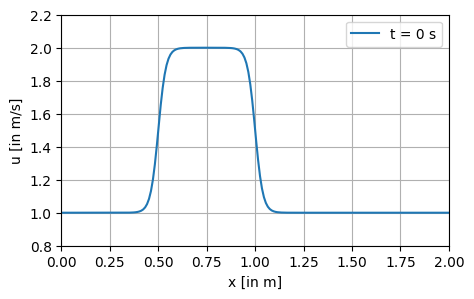

In [120]:
# visualize analytical solution
x_arr   = np.linspace(0, x_max, nx)
u_init  = create_u_initial(x_arr)

plt.figure(figsize=(5, 3))
plt.plot(x_arr, u_init, label="t = 0 s")
plt.axis([0, 2, 0.8, 2.2])
plt.xlabel("x [in m]")
plt.ylabel("u [in m/s]")
plt.grid("on")
plt.legend()


## Implementation

The first argument to `pde` is the network input, i.e. the x and y coordinates. The second argument is the network output `u` which is comprised of the 3 different output solutions i.e., velocity u, velocity v, and pressure p.

### Governing PDE

In [121]:
# PDE residual  
def pde(X, u):  
    du_dx = dde.grad.jacobian(u, X, i=0, j=0)  
    du_dt = dde.grad.jacobian(u, X, i=0, j=1)  
    return du_dt + u*du_dx  


### Initial Condition and Boundary Condition

In [122]:
# # Initial Conditions
# def initial_condition(X):    
#     x_arr       = X[:, 0:1]
#     u_initial   = create_u_initial(x_arr)
#     return u_initial

# Initial Condition (hard-constrint)
def output_transform(X, y_pred):
    x_arr   = X[:, 0:1]
    t_arr   = X[:, 1:2]
    # u_ic    = create_u_initial(x_arr, to_tensor=True)

    k       = 25.0
    u_ic    = 1.0 + 0.5 * (torch.tanh(k * (x_arr - 0.5)) - torch.tanh(k * (x_arr - 1.0)))
    
    return u_ic + t_arr*y_pred

# Boundary Conditions
def boundary_left(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 0)


## Create `GeometryXTime` Domain 

Next, we consider the boundary condition. `on_boundary` is chosen here to use the whole boundary of the computational domain as the boundary condition. We include `on_boundary` as the BCs in the `DirichletBC` function of DeepXDE.

In [123]:
# Geometry setup  
geom        = dde.geometry.Interval(0, x_max)
timedomain  = dde.geometry.TimeDomain(0, t_end)
geomtime    = dde.geometry.GeometryXTime(geom, timedomain)


## Create `TimePDE` Data

In [124]:
# Boundary conditions - using DirichletBC at spatial boundaries  
bc_left = dde.icbc.DirichletBC(geomtime, lambda x: 1.0, boundary_left)

# Create TimePDE data  
data = dde.data.TimePDE(  
    geomtime,  
    pde,  
    [bc_left],  
    num_domain=2500,  
    num_boundary=100,
    num_test=2500,  
)


## Create PINNs Model

The training residual points imside the domain is 2601, and the number of training points sampled on the boundary is 400. 100000 test points were used in the `PDE`.

Next, we choose the network. We use a fully connected neural network of 4 hidden layers, 3 outputs and width 50


In [125]:
# Neural network
# -> inputs  : x and t
# -> outputs : u
net = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")  

# Apply the transform to network BEFORE creating the model
net.apply_output_transform(output_transform)

# Model
model = dde.Model(data, net)


## Training 

The PDE and the network have now been defined. Next, we build a `Model` and choose the optimizer and learning rate.

- For hyperbolic PDEs with sharp gradients (like your discontinuous initial condition), consider using `PDEPointResampler` to adaptively sample points during training.

In [126]:
# Training  
model.compile("adam", lr=0.001)
# losshistory, train_state = model.train(iterations=15_000)
pde_resampler = dde.callbacks.PDEPointResampler(period=1000)
losshistory, train_state = model.train(iterations=25_000, callbacks=[pde_resampler])


Compiling model...
'compile' took 0.000278 s

Training model...

Step      Train loss              Test loss               Test metric
0         [1.67e+01, 3.03e-05]    [1.73e+01, 3.03e-05]    []  
1000      [2.37e-01, 1.80e-05]    [1.94e-01, 1.80e-05]    []  
2000      [1.33e-01, 3.16e-06]    [1.35e-01, 3.16e-06]    []  
3000      [1.13e-01, 7.34e-07]    [1.35e-01, 7.34e-07]    []  
4000      [1.07e-01, 6.47e-07]    [1.50e-01, 6.47e-07]    []  
5000      [9.21e-02, 1.68e-06]    [2.35e-01, 1.68e-06]    []  
6000      [8.38e-02, 2.92e-07]    [5.36e-01, 2.92e-07]    []  
7000      [1.77e-01, 1.34e-06]    [1.69e-01, 1.34e-06]    []  
8000      [1.20e-01, 4.20e-07]    [1.37e-01, 4.20e-07]    []  
9000      [1.02e-01, 8.13e-07]    [1.44e-01, 8.13e-07]    []  
10000     [9.60e-02, 2.35e-07]    [1.81e-01, 2.35e-07]    []  
11000     [7.36e-02, 4.70e-06]    [3.44e-01, 4.70e-06]    []  
12000     [7.64e-02, 8.62e-08]    [3.11e-01, 8.62e-08]    []  
13000     [4.45e-02, 8.96e-08]    [6.19e-01, 8

In [97]:
# # Optional: Continue with L-BFGS for better convergence
# model.compile("L-BFGS-B")
# losshistory, train_state = model.train() # callbacks=[pde_resampler]



## Save and Load Model

### Save Model

In [128]:
# # Save the model after training
# path_root = r"C:\Users\Neelay\Documents\#Learning\PINNs"
# model.save(path_root + r"\models\step_2_hard_nn64x4_25k")


### Load Model

In [129]:
# # Create the same model structure
# bcs     = [boundary_condition_u, boundary_condition_v, boundary_condition_right_p]
# data    = dde.data.PDE(spatial_domain, pde, bcs, num_domain=2601, num_boundary=400, num_test=100000)
# net     = dde.nn.FNN([2] + 3*[20] + [1], "tanh", "Glorot normal")
# model   = dde.Model(data, net)
# model.compile("adam", lr=0.001)

# # Path to your saved model file
# checkpoint_path = r"models/step_1_10k-10000.pt"

# # Load the checkpoint dictionary safely
# checkpoint = torch.load(checkpoint_path, weights_only=True)

# # Inject the weights directly into the network structure
# model.net.load_state_dict(checkpoint["model_state_dict"])

# print("Model weights loaded successfully!")


## Visualize Results

Text(0.5, 1.0, '1D Linear Convection')

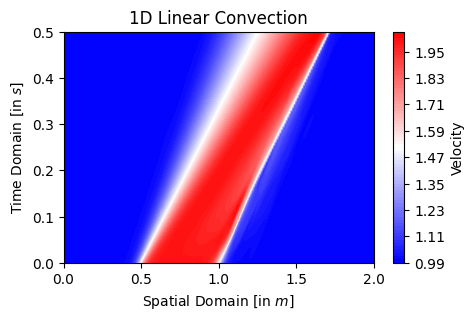

In [130]:
from matplotlib.colors import ListedColormap

# Create a grid for full 2D visualization  
x_grid = np.linspace(0, x_max, nx)
t_grid = np.linspace(0, t_end, nt)
X_grid, T_grid  = np.meshgrid(x_grid, t_grid)
grid_points     = np.column_stack([X_grid.ravel(), T_grid.ravel()])

# Predict u, v, p on the grid  
u_pinns = model.predict(grid_points).reshape(X_grid.shape)

# Plot contour
plt.figure(figsize=(5, 3))
# Defines a sharp split between blue and red
# cmap_two_tone = ListedColormap(['blue', 'red'])
# contour = plt.contourf(X_grid, T_grid, u_grid, levels=100, cmap=cmap_two_tone)
contour = plt.contourf(X_grid, T_grid, u_pinns, levels=100, cmap="bwr")
plt.colorbar(contour, label='Velocity')

plt.xlabel('Spatial Domain [in $m$]')
plt.ylabel('Time Domain [in $s$]')
plt.title('1D Linear Convection')
# plt.axis('equal')



------------

# FDM Explicit Scheme

In [131]:
import numpy as np 
import matplotlib.pyplot as plt

def create_u_initial(x_arr):
    
    k           = 25.0 # Steepness factor
    step_up     = np.tanh(k * (x_arr - 0.5))
    step_down   = np.tanh(k * (x_arr - 1.0))
    u_initial   = 1 + 0.5*(step_up - step_down)

    return u_initial


In [132]:
# space and time discretization
x_max   = 2
dx      = 0.01
nx      = int(x_max / dx)
x_arr   = np.linspace(0, 2, nx)

t_end   = 0.5 # in s
dt      = 0.001 # in s
nt      = int( t_end/dt ) # nt is the number of timesteps we want to calculate

u_init  = create_u_initial(x_arr)
U       = np.zeros((nt, nx)) # store u for all time-steps
U[0, :] = u_init # initial condition
U[:, 0] = u_init[0] # left bouundary condition

u_max   = max(u_init)
cfl     = u_max*dt/dx
print(f"CFL Number: u_max*dt/dx = {cfl:.3f}")

if (cfl > 0.5):
    raise ValueError("CFL number is u_max*dt/dx = {cfl}, which is greater than 0.5. Either reduce `dt` or increase `dx`.")

# FDM
for n in range(1, nt):  # iterate through time
    U[n, 1:] = U[n-1, 1:] - U[n-1, 1:]*dt*(U[n-1, 1:] - U[n-1, 0:-1]) / dx # FTBS
    
    # # For simpler execution of explicit scheme, comment the above line and uncomment the 2 lines below
    # for i in range(1, nx):  # iterate through space
    #     U[n, i] = U[n-1, i] - U[n-1, i]*dt*(U[n-1, i] - U[n-1, i-1]) / dx
        


CFL Number: u_max*dt/dx = 0.200


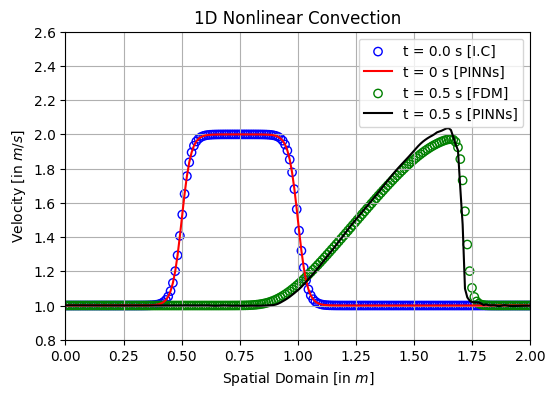

In [133]:
# Plot the results
idx = -1 # int(nt / 2)

plt.figure(figsize=(6, 4))

plt.scatter(x_arr, u_init, facecolors='none', edgecolors='blue', label="t = 0.0 s [I.C]")
plt.plot(X_grid[0, :], u_pinns[0, :], "r", label="t = 0 s [PINNs]")

plt.scatter(x_arr, U[idx, :], facecolors='none', edgecolors='g', label=f"t = {t_end} s [FDM]")
plt.plot(X_grid[idx, :], u_pinns[idx, :], "k", label=f"t = {t_end} s [PINNs]")

plt.title("1D Nonlinear Convection")
plt.xlabel("Spatial Domain [in $m$]")
plt.ylabel("Velocity [in $m/s$]")
plt.axis([0, 2, 0.8, 2.6])
plt.grid("on")
plt.legend()


Text(0, 0.5, 'Time Domain [in $s$]')

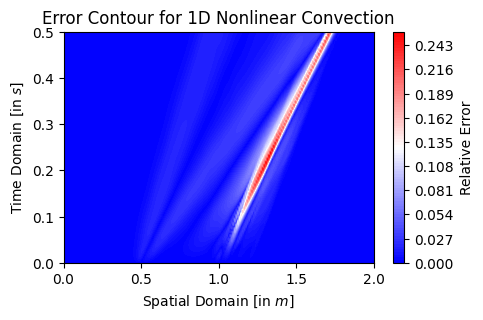

In [134]:
# Compute error 
u_max   = max(u_init)
u_error = abs(U - u_pinns) / u_max

# Plot Error Contour
plt.figure(figsize=(5, 3))
contour = plt.contourf(X_grid, T_grid, u_error, levels=100, cmap="bwr")
plt.colorbar(contour, label='Relative Error', format='%.3f')

plt.title('Error Contour for 1D Nonlinear Convection')
plt.xlabel('Spatial Domain [in $m$]')
plt.ylabel('Time Domain [in $s$]')

